# viz

> mempool.space-style block cards: per-tx feerate histograms, summary stats, and a recent-block fee-rate sparkline.

In [1]:
#| default_exp viz

In [2]:
#| hide
from nbdev.showdoc import *

In [3]:
#| export
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timezone
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.figure import Figure

from slashbtc.core import Chain

## Per-tx feerates

For each non-coinbase tx in the block we want `(vsize, feerate_sat_per_vB)`. We use `getblock` verbosity 3 — it returns each input's prevout inline, so fee = sum(prevouts) − sum(outputs). Requires Bitcoin Core ≥ 25.


In [4]:
#| export
_BLOCK_CACHE: dict[str, tuple[dict, list[tuple[int, float]]]] = {}

def block_feerates(
    chain: Chain, height_or_hash: int | str
) -> tuple[dict, list[tuple[int, float]]]:
    """Return `(block_dict, [(vsize, feerate_sat_per_vB), ...])` skipping coinbase.

    Memoized by input — calling twice with the same height (or hash) is free.
    Clear with `_BLOCK_CACHE.clear()` if you suspect a reorg.
    """
    key = str(height_or_hash)
    if key in _BLOCK_CACHE:
        return _BLOCK_CACHE[key]
    blk = chain.block(height_or_hash, verbosity=3)
    rows: list[tuple[int, float]] = []
    for tx in blk["tx"][1:]:
        try:
            vin = sum(v["prevout"]["value"] for v in tx["vin"])
        except KeyError:
            continue
        vout = sum(o["value"] for o in tx["vout"])
        fee_sat = round((vin - vout) * 1e8)
        vsize = tx["vsize"]
        if vsize > 0 and fee_sat >= 0:
            rows.append((vsize, fee_sat / vsize))
    result = (blk, rows)
    _BLOCK_CACHE[key] = result
    if "hash" in blk:
        _BLOCK_CACHE[blk["hash"]] = result
    return result

## Bucketing

A block has 2k–4k txs — too many to draw one bar per tx. Bucket them into *equal-vsize chunks* sorted by feerate. Each bucket's bar length = its total vsize, color = its mean feerate. Equal-vsize chunks (rather than equal-count) make the bars proportional to block weight, matching the mempool.space style.

In [5]:
#| export
def feerate_buckets(
    rows: Iterable[tuple[int, float]], n_bins: int = 24
) -> tuple[list[float], list[int]]:
    """Bucket txs into `n_bins` equal-vsize chunks ordered low→high feerate."""
    rows = sorted(rows, key=lambda r: r[1])  # ascending feerate
    if not rows:
        return [], []
    total = sum(v for v, _ in rows)
    target = total / n_bins
    feerates: list[float] = []
    vsizes: list[int] = []
    cur_v, cur_fw = 0, 0.0
    for v, fr in rows:
        cur_v += v
        cur_fw += fr * v
        if cur_v >= target:
            feerates.append(cur_fw / cur_v)
            vsizes.append(cur_v)
            cur_v, cur_fw = 0, 0.0
    if cur_v > 0:
        feerates.append(cur_fw / cur_v)
        vsizes.append(cur_v)
    return feerates, vsizes

## Block summary

`getblockstats` is fast (single call) and returns everything we need for the stats panel. Sparkline is just N more of the same.

In [6]:
#| export
def block_summary(chain: Chain, height: int) -> dict:
    "Aggregate block stats from `getblockstats`."
    return chain.rpc.call("getblockstats", height)

In [7]:
#| export
def feerate_trend(chain: Chain, end_height: int, n: int = 20) -> list[float]:
    "Median feerate (sat/vB) for the `n` blocks ending at `end_height` (inclusive)."
    heights = range(end_height - n + 1, end_height + 1)
    with ThreadPoolExecutor(max_workers=8) as pool:
        stats = list(pool.map(
            lambda h: chain.rpc.call("getblockstats", h, ["feerate_percentiles"]),
            heights,
        ))
    return [s["feerate_percentiles"][2] for s in stats]

## Rendering

Yellow→black colormap matches the screenshot: low feerate = warm, high feerate = dark. Bars are drawn high→low feerate (dark on top); flip to taste.

In [8]:
#| export
_FEE_CMAP = LinearSegmentedColormap.from_list("fee", ["#fff5b8", "#f5a623", "#1a1a1a"])

def _fmt_age(ts: int, now: int | None = None) -> str:
    now = now or int(datetime.now(tz=timezone.utc).timestamp())
    secs = max(0, now - ts)
    if secs < 60: return f"{secs}s ago"
    if secs < 3600: return f"{secs // 60}m ago"
    if secs < 86400: return f"{secs // 3600}h ago"
    return f"{secs // 86400}d ago"

In [9]:
#| export
def block_card(
    chain: Chain,
    height: int,
    fig: Figure | None = None,
    with_sparkline: bool = True,
    btc_usd: float | None = None,
    trend: list[float] | None = None,
) -> Figure:
    """Render one mempool.space-style block row.

    Pass a precomputed `trend` (list of medians) to skip the per-card sparkline
    RPCs — useful when rendering many cards back-to-back.
    """
    _blk, rows = block_feerates(chain, height)
    s = block_summary(chain, height)
    feerates, vsizes = feerate_buckets(rows, n_bins=24)

    fig = fig or plt.figure(figsize=(13, 2.4))
    gs = fig.add_gridspec(
        1, 6,
        width_ratios=[1.4, 2.0, 1.0, 1.0, 1.4, 1.6],
        wspace=0.05,
    )

    ax_h = fig.add_subplot(gs[0, 0])
    if feerates:
        norm = Normalize(vmin=min(feerates), vmax=max(feerates))
        colors = [_FEE_CMAP(norm(fr)) for fr in feerates]
        y = np.arange(len(feerates))
        ax_h.barh(y, vsizes, color=colors, edgecolor="none", height=0.85)
        ax_h.invert_yaxis()
    ax_h.set_axis_off()

    ax_id = fig.add_subplot(gs[0, 1])
    ax_id.axis("off")
    ts = datetime.fromtimestamp(s["time"], tz=timezone.utc).strftime("%b %-d, %Y  %H:%M:%S")
    ax_id.text(0, 0.65, f"{s['height']:,}", fontsize=22, weight="bold")
    ax_id.text(0, 0.30, ts, fontsize=9, color="gray")

    ax_tx = fig.add_subplot(gs[0, 2])
    ax_tx.axis("off")
    ax_tx.text(0, 0.65, f"{s['txs']:,}", fontsize=18)
    ax_tx.text(0, 0.45, "txs", fontsize=10, color="gray")

    ax_sz = fig.add_subplot(gs[0, 3])
    ax_sz.axis("off")
    ax_sz.text(0, 0.65, f"{s['total_size']/1e6:.2f}", fontsize=18)
    ax_sz.text(0, 0.45, "MB", fontsize=10, color="gray")

    ax_fee = fig.add_subplot(gs[0, 4])
    ax_fee.axis("off")
    fee_btc = s['totalfee'] / 1e8
    ax_fee.text(0, 0.65, f"{fee_btc:.2f}", fontsize=18)
    ax_fee.text(0.45, 0.68, "BTC", fontsize=9, color="gray")
    if btc_usd is not None:
        ax_fee.text(0, 0.30, f"${fee_btc * btc_usd:,.0f}", fontsize=10, color="gray")

    ax_md = fig.add_subplot(gs[0, 5])
    ax_md.axis("off")
    median_fr = s['feerate_percentiles'][2]
    ax_md.text(0, 0.85, "median fee", fontsize=9, color="gray")
    ax_md.text(0, 0.55, f"{median_fr} sat/vB", fontsize=15, weight="bold")
    if with_sparkline:
        try:
            spark = trend if trend is not None else feerate_trend(chain, height, n=20)
            inset = ax_md.inset_axes([0, 0, 1, 0.35])
            inset.plot(spark, color="#f5a623", linewidth=1.5)
            inset.axis("off")
        except Exception:
            pass

    age = _fmt_age(s['time'])
    fig.text(0.005, 0.5, age, fontsize=10, va='center', color='gray')
    return fig

In [10]:
#| export
def blocks_view(
    chain: Chain,
    n: int = 6,
    end_height: int | None = None,
    btc_usd: float | None = None,
    spark_window: int = 20,
    max_workers: int = 6,
) -> Figure:
    """Stack `n` block cards newest→oldest, like the mempool.space block list.

    Fetches the `n` blocks in parallel and computes the sparkline window once,
    so total RPC cost is roughly `n` big calls + `n + spark_window - 1` small.
    """
    end_height = end_height or chain.height()
    heights = [end_height - i for i in range(n)]

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        list(pool.map(lambda h: block_feerates(chain, h), heights))

    trend_low = end_height - n - spark_window + 2
    full_trend = feerate_trend(chain, end_height, n=n + spark_window - 1)

    fig = plt.figure(figsize=(13, 2.4 * n))
    subfigs = fig.subfigures(n, 1, hspace=0.0)
    if n == 1:
        subfigs = [subfigs]
    for i, sf in enumerate(subfigs):
        h = heights[i]
        offset = h - trend_low + 1
        spark = full_trend[max(0, offset - spark_window):offset]
        block_card(chain, h, fig=sf, btc_usd=btc_usd, trend=spark)
    return fig

## Demo

Tagged `notest` so `nbdev_test` skips it; un-skip when your RPC tunnel is up.

RemoteProtocolError: peer closed connection without sending complete message body (received 12418958 bytes, expected 12871406)

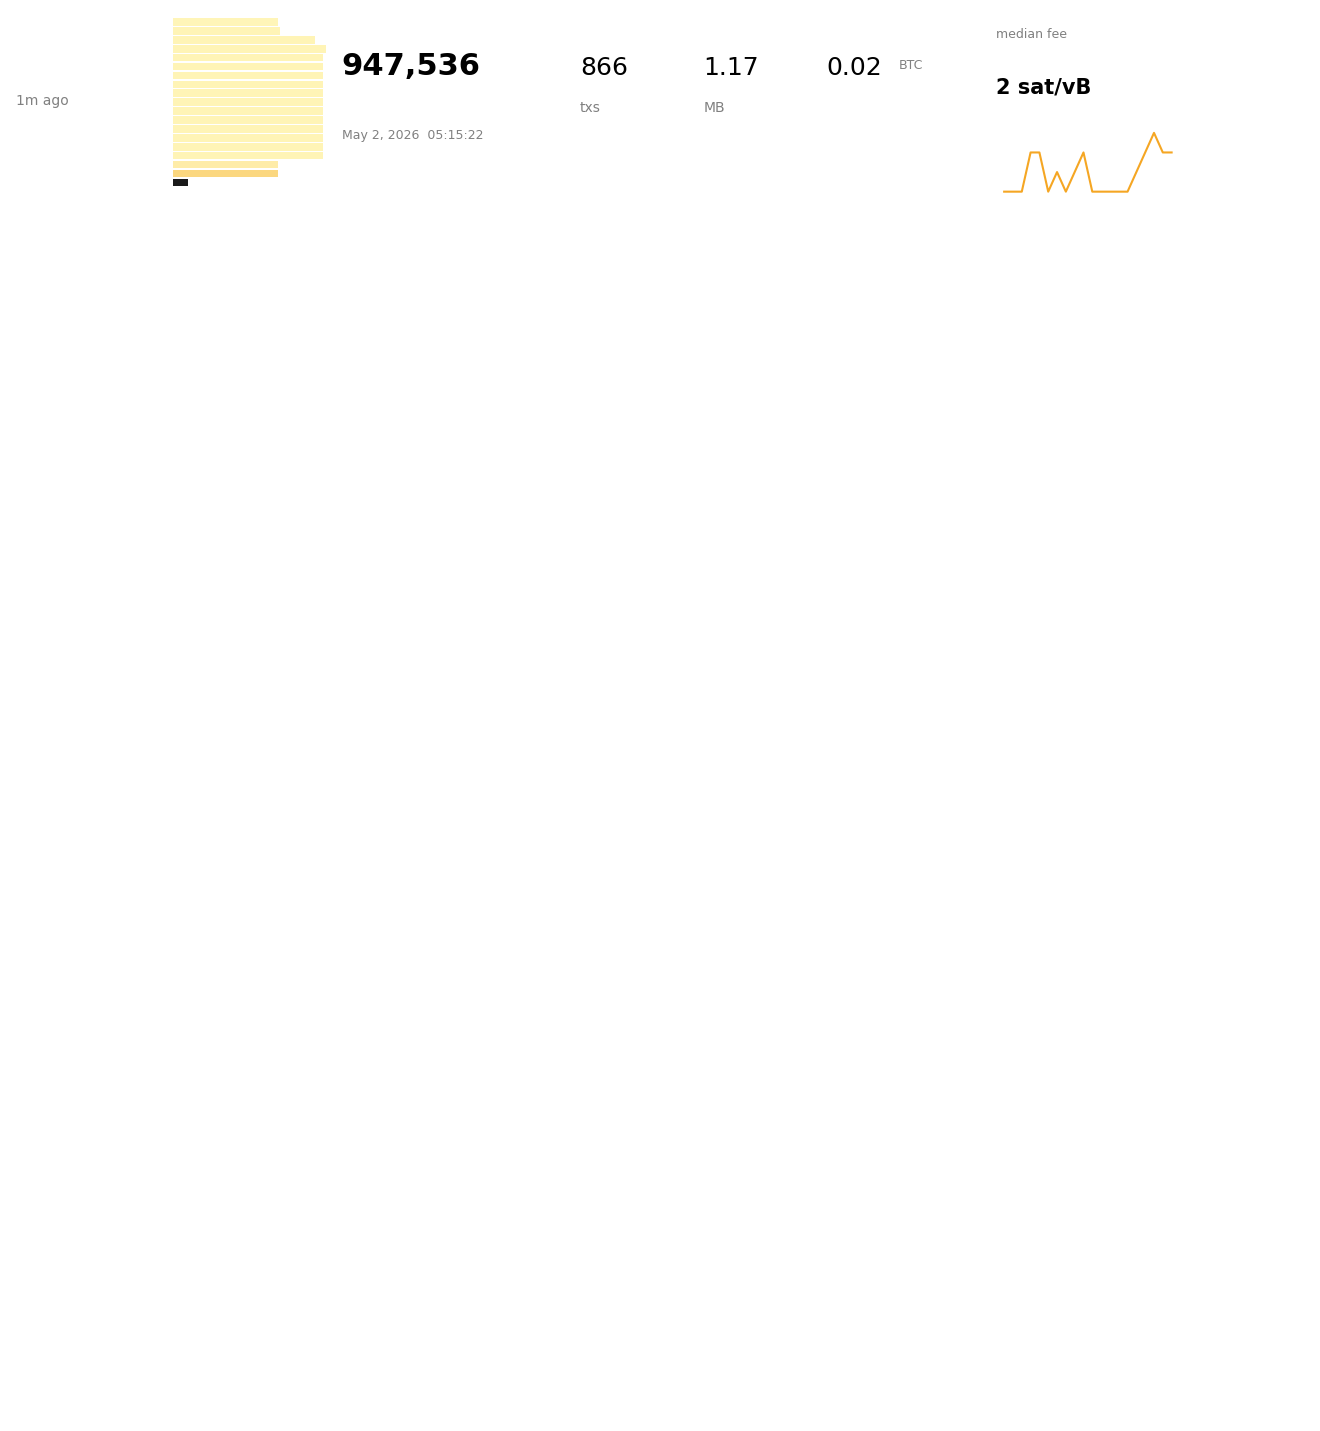

In [11]:
#| eval: false
#| notest
chain = Chain()
fig = blocks_view(chain, n=6)
fig

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()